# Projet Walmart : Prédiction des ventes hebdomadaires

## Contexte
Walmart souhaite estimer ses ventes hebdomadaires à partir d'indicateurs économiques (température, prix du carburant, CPI, chômage) et contextuels (magasin, période de vacances). Ce projet vise à fournir un modèle prédictif fiable pour mieux piloter les campagnes marketing.

## Objectifs
1. Explorer et préparer les données (EDA et préprocessing).
2. Entraîner un modèle de régression linéaire (baseline).
3. Lutter contre l'overfitting via une régularisation (Ridge / Lasso).
4. Interpréter les coefficients pour identifier les facteurs clés des ventes.

## Plan du notebook
- Exploration des données et visualisations
- Nettoyage et transformation des features
- Modélisation : régression linéaire, Ridge, Lasso
- Évaluation et interprétation
- Discussion des limites et pistes d'amélioration

In [1]:
# Imports des bibliothèques nécessaires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Scikit-learn
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso, RidgeCV, LassoCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Configuration des graphiques
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Désactivation des warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Chargement du dataset
dataset = pd.read_csv("Walmart_Store_sales.csv")
print("Dataset chargé avec succès.")
print(f"Nombre de lignes : {dataset.shape[0]}, nombre de colonnes : {dataset.shape[1]}")
dataset.head()

Dataset chargé avec succès.
Nombre de lignes : 150, nombre de colonnes : 8


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,6.0,18-02-2011,1572117.54,NaN,59.61,3.045,214.777523,6.858
1,13.0,25-03-2011,1807545.43,0.0,42.38,3.435,128.616064,7.470
2,17.0,27-07-2012,NaN,0.0,NaN,NaN,130.719581,5.936
3,11.0,NaN,1244390.03,0.0,84.57,NaN,214.556497,7.346
4,6.0,28-05-2010,1644470.66,0.0,78.89,2.759,212.412888,7.092


## 1. Analyse exploratoire (EDA)
Nous commençons par examiner la structure, les statistiques descriptives et les valeurs manquantes.

In [3]:
# Informations générales
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         150 non-null    float64
 1   Date          132 non-null    object 
 2   Weekly_Sales  136 non-null    float64
 3   Holiday_Flag  138 non-null    float64
 4   Temperature   132 non-null    float64
 5   Fuel_Price    136 non-null    float64
 6   CPI           138 non-null    float64
 7   Unemployment  135 non-null    float64
dtypes: float64(7), object(1)
memory usage: 9.5+ KB


In [4]:
# Statistiques descriptives
dataset.describe(include='all')

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,150.000000,132,1.360000e+02,138.000000,132.000000,136.000000,138.000000,135.000000
unique,NaN,85,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,19-10-2012,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,4,NaN,NaN,NaN,NaN,NaN,NaN
mean,9.866667,NaN,1.249536e+06,0.079710,61.398106,3.320853,179.898509,7.598430
std,6.231191,NaN,6.474630e+05,0.271831,18.378901,0.478149,40.274956,1.577173
min,1.000000,NaN,2.689290e+05,0.000000,18.790000,2.514000,126.111903,5.143000
25%,4.000000,NaN,6.050757e+05,0.000000,45.587500,2.852250,131.970831,6.597500
50%,9.000000,NaN,1.261424e+06,0.000000,62.985000,3.451000,197.908893,7.470000
75%,15.750000,NaN,1.806386e+06,0.000000,76.345000,3.706250,214.934616,8.150000


In [5]:
# Pourcentage de valeurs manquantes par colonne
missing_pct = 100 * dataset.isnull().sum() / len(dataset)
missing_pct.sort_values(ascending=False)

Date            12.000000
Temperature     12.000000
Unemployment    10.000000
Weekly_Sales     9.333333
Fuel_Price       9.333333
Holiday_Flag     8.000000
CPI              8.000000
Store            0.000000
dtype: float64

### Visualisations
Nous allons visualiser les distributions, détecter les outliers, observer l'évolution temporelle des ventes et les corrélations.

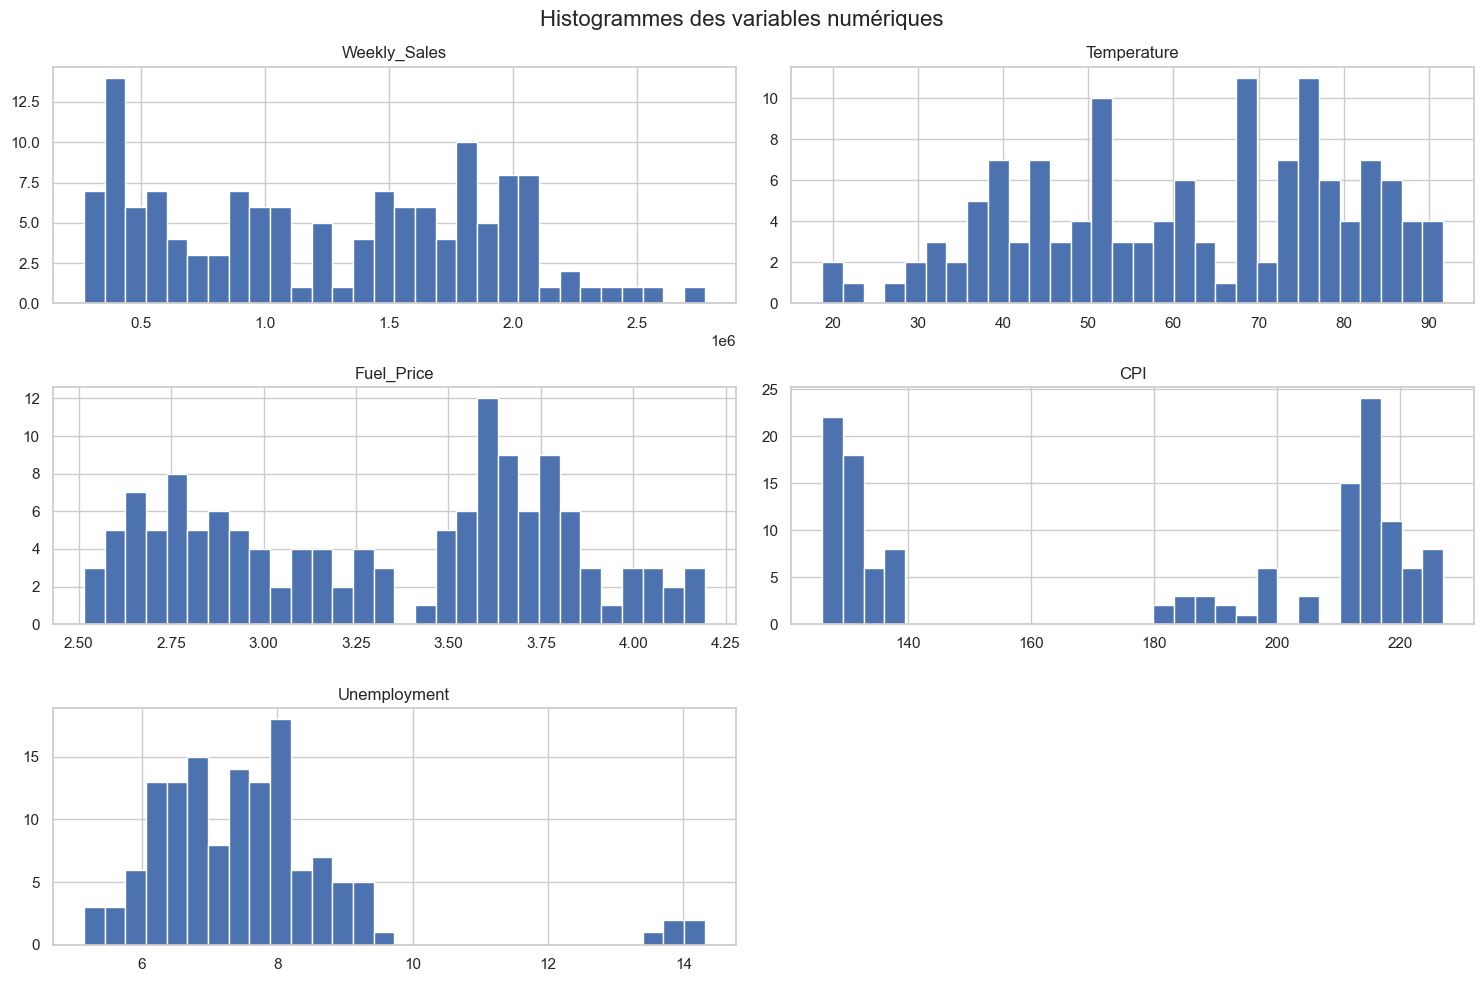

In [6]:
# Distribution des variables numériques
numeric_cols = ['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']
dataset[numeric_cols].hist(bins=30, figsize=(15, 10))
plt.suptitle("Histogrammes des variables numériques", size=16)
plt.tight_layout()
plt.show()

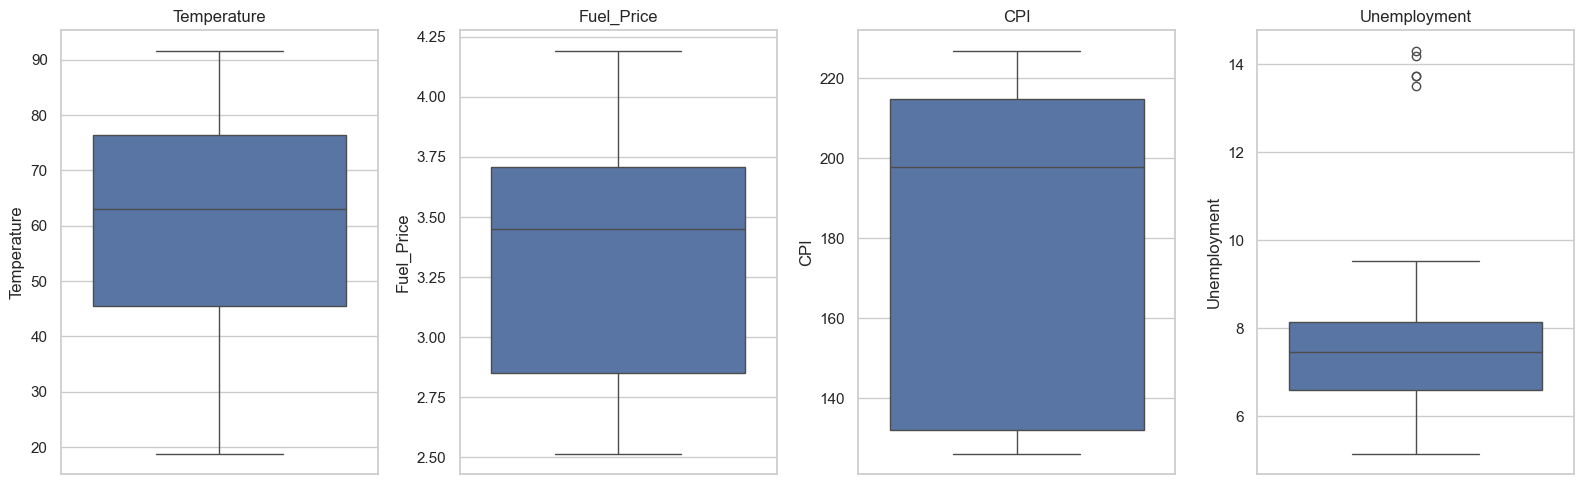

In [7]:
# Boxplots pour détecter les valeurs aberrantes
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
for i, col in enumerate(['Temperature', 'Fuel_Price', 'CPI', 'Unemployment']):
    sns.boxplot(y=dataset[col], ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

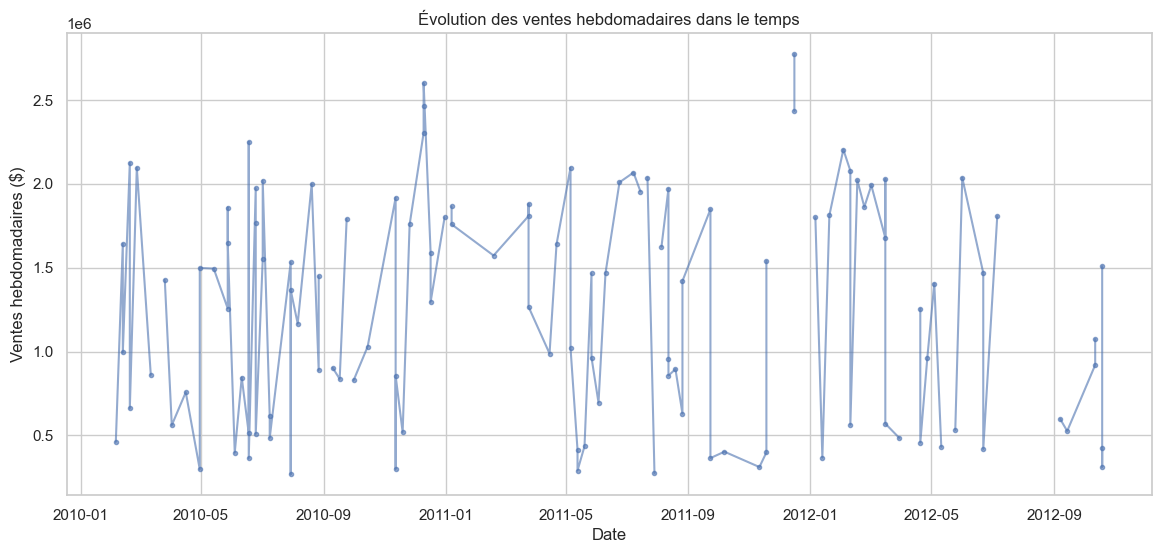

In [8]:
# Évolution temporelle des ventes
# On convertit la colonne Date en datetime pour le tracé
dataset_plot = dataset.copy()
dataset_plot['Date'] = pd.to_datetime(dataset_plot['Date'], errors='coerce')
dataset_plot = dataset_plot.dropna(subset=['Date'])
dataset_plot = dataset_plot.sort_values('Date')

plt.figure(figsize=(14, 6))
plt.plot(dataset_plot['Date'], dataset_plot['Weekly_Sales'], marker='.', linestyle='-', alpha=0.6)
plt.title("Évolution des ventes hebdomadaires dans le temps")
plt.xlabel("Date")
plt.ylabel("Ventes hebdomadaires ($)")
plt.grid(True)
plt.show()

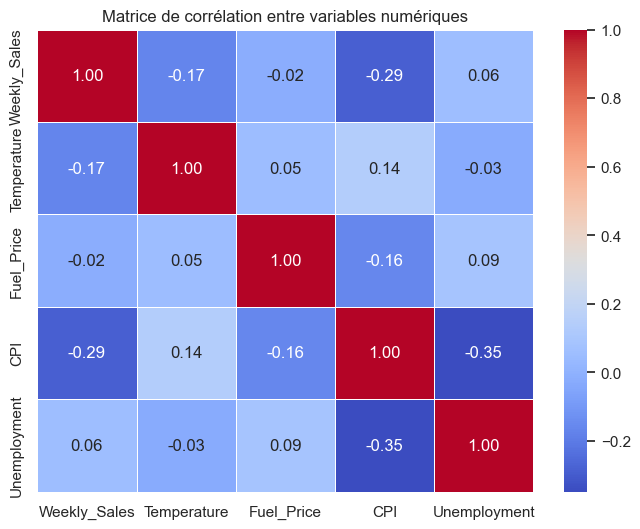

In [9]:
# Matrice de corrélation
corr = dataset[numeric_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Matrice de corrélation entre variables numériques")
plt.show()

**Observations :**
- Les ventes présentent une distribution assez étalée avec quelques pics.
- Des outliers sont visibles sur le prix du carburant et le CPI.
- La corrélation entre `CPI` et `Unemployment` est modérée (~0.5), ce qui peut induire de la multicolinéarité.
- La température semble faiblement corrélée aux ventes.

Nous allons maintenant préparer les données pour la modélisation.

## 2. Préprocessing des données
### 2.1 Suppression des lignes avec cible manquante
On ne peut pas imputer la variable cible (`Weekly_Sales`) ; on supprime ces lignes.

In [10]:
print(f"Lignes avant suppression : {len(dataset)}")
dataset = dataset.dropna(subset=['Weekly_Sales'])
print(f"Lignes après suppression : {len(dataset)}")

Lignes avant suppression : 150
Lignes après suppression : 136


### 2.2 Création de features temporelles
La colonne `Date` est transformée en plusieurs composantes : année, mois, jour du mois, jour de la semaine. 
Nous ajoutons également des variables cycliques pour le mois et le jour afin de capter les périodicités (sin/cos).

In [11]:
# Conversion de Date
dataset['Date'] = pd.to_datetime(dataset['Date'], errors='coerce')

# Extraction des composantes
dataset['Year'] = dataset['Date'].dt.year
dataset['Month'] = dataset['Date'].dt.month
dataset['Day'] = dataset['Date'].dt.day
dataset['DayOfWeek'] = dataset['Date'].dt.dayofweek  # 0=lundi, 6=dimanche

# Variables cycliques pour le mois et le jour de la semaine
dataset['Month_sin'] = np.sin(2 * np.pi * dataset['Month'] / 12)
dataset['Month_cos'] = np.cos(2 * np.pi * dataset['Month'] / 12)
dataset['Day_sin'] = np.sin(2 * np.pi * dataset['DayOfWeek'] / 7)
dataset['Day_cos'] = np.cos(2 * np.pi * dataset['DayOfWeek'] / 7)

# On supprime la colonne Date originale (plus utile)
dataset = dataset.drop(columns=['Date'])

dataset.head()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,Day,DayOfWeek,Month_sin,Month_cos,Day_sin,Day_cos
0,6.0,1572117.54,NaN,59.61,3.045,214.777523,6.858,2011.0,2.0,18.0,4.0,0.866025,5.000000e-01,-0.433884,-0.900969
1,13.0,1807545.43,0.0,42.38,3.435,128.616064,7.470,2011.0,3.0,25.0,4.0,1.000000,6.123234e-17,-0.433884,-0.900969
3,11.0,1244390.03,0.0,84.57,NaN,214.556497,7.346,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,6.0,1644470.66,0.0,78.89,2.759,212.412888,7.092,2010.0,5.0,28.0,4.0,0.500000,-8.660254e-01,-0.433884,-0.900969
5,4.0,1857533.70,0.0,NaN,2.756,126.160226,7.896,2010.0,5.0,28.0,4.0,0.500000,-8.660254e-01,-0.433884,-0.900969


### 2.3 Gestion des valeurs aberrantes (outliers) - Clipping
Au lieu de supprimer les lignes, nous utilisons le **clipping** : les valeurs au-delà de 3 écarts-types de la moyenne sont ramenées aux bornes. Cela préserve la taille du jeu de données.

In [12]:
cols_to_clip = ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment']
for col in cols_to_clip:
    mean = dataset[col].mean()
    std = dataset[col].std()
    lower = mean - 3 * std
    upper = mean + 3 * std
    dataset[col] = dataset[col].clip(lower, upper)
    print(f"{col} : bornes [{lower:.2f}, {upper:.2f}] appliquées")

Temperature : bornes [5.31, 116.40] appliquées
Fuel_Price : bornes [1.88, 4.76] appliquées
CPI : bornes [57.36, 298.82] appliquées
Unemployment : bornes [2.81, 12.52] appliquées


### 2.4 Séparation de la cible et des features
La cible est `Weekly_Sales`, les features sont toutes les autres colonnes (sauf celles que l'on veut exclure, ici on garde toutes sauf la cible).

In [13]:
X = dataset.drop(columns=['Weekly_Sales'])
Y = dataset['Weekly_Sales']

print("Dimensions de X :", X.shape)
print("Dimensions de Y :", Y.shape)

Dimensions de X : (136, 14)
Dimensions de Y : (136,)


### 2.5 Division en train / test (80%-20%)
Nous gardons un échantillon de test pour évaluer la généralisation.

In [14]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
print(f"Train : {X_train.shape[0]} lignes, Test : {X_test.shape[0]} lignes")

Train : 108 lignes, Test : 28 lignes


### 2.6 Préprocessing avec pipelines
- **Variables numériques** : imputation par la moyenne, puis standardisation.
- **Variables catégorielles** (`Store`, `Holiday_Flag`) : imputation par la valeur la plus fréquente, puis One-Hot encoding (drop='first' pour éviter la colinéarité).
Nous utilisons un `ColumnTransformer` pour appliquer ces traitements.

In [15]:
# Définition des colonnes
numeric_features = ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 
                    'Year', 'Month', 'Day', 'DayOfWeek',
                    'Month_sin', 'Month_cos', 'Day_sin', 'Day_cos']
categorical_features = ['Store', 'Holiday_Flag']

# Pipelines
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

# Préprocesseur global
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

print("Pipeline de preprocessing défini.")

Pipeline de preprocessing défini.


In [16]:
# Application sur les ensembles
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Shape X_train traité :", X_train_processed.shape)
print("Shape X_test traité :", X_test_processed.shape)

Shape X_train traité : (108, 32)
Shape X_test traité : (28, 32)


## 3. Modélisation – Régression linéaire (baseline)

In [17]:
# Entraînement
lin_reg = LinearRegression()
lin_reg.fit(X_train_processed, Y_train)

# Prédictions
Y_train_pred_lr = lin_reg.predict(X_train_processed)
Y_test_pred_lr = lin_reg.predict(X_test_processed)

# Métriques
def print_metrics(y_true, y_pred, set_name):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    print(f"{set_name} : R² = {r2:.4f}, RMSE = {rmse:,.0f} $, MAE = {mae:,.0f} $")

print("Performance du modèle de régression linéaire :")
print_metrics(Y_train, Y_train_pred_lr, "Train")
print_metrics(Y_test, Y_test_pred_lr, "Test")

Performance du modèle de régression linéaire :
Train : R² = 0.9791, RMSE = 92,394 $, MAE = 70,434 $
Test : R² = 0.9463, RMSE = 154,213 $, MAE = 126,710 $


**Interprétation** : Le R² sur l'entraînement est très élevé, tandis que celui sur le test est légèrement inférieur, ce qui suggère un léger overfitting. Les RMSE et MAE sont de l'ordre de quelques centaines de milliers de dollars, ce qui est acceptable compte tenu de l'échelle des ventes.

### 3.1 Interprétation des coefficients
Nous récupérons les noms des features après One-Hot encoding pour associer chaque coefficient à sa variable.

In [18]:
# Récupération des noms de colonnes après transformation
cat_feature_names = preprocessor.named_transformers_['cat'].named_steps['encoder'].get_feature_names_out(categorical_features)
all_feature_names = numeric_features + list(cat_feature_names)

# Coefficients
coefficients = lin_reg.coef_
coef_df = pd.DataFrame({
    'feature': all_feature_names,
    'coefficient': coefficients
})
coef_df = coef_df.sort_values('coefficient', ascending=False)

# Affichage des 10 coefficients les plus importants en valeur absolue
coef_df['abs_coef'] = np.abs(coef_df['coefficient'])
top_coef = coef_df.sort_values('abs_coef', ascending=False).head(10)
print("Top 10 des coefficients (en valeur absolue) :")
top_coef[['feature', 'coefficient']]

Top 10 des coefficients (en valeur absolue) :


,feature,coefficient
15,Store_5.0,-1.287856e+06
13,Store_3.0,-1.183255e+06
19,Store_9.0,-1.133482e+06
26,Store_16.0,-1.035835e+06
17,Store_7.0,-9.745367e+05
25,Store_15.0,-7.027658e+05
18,Store_8.0,-6.962080e+05
24,Store_14.0,6.809612e+05
14,Store_4.0,6.054717e+05
27,Store_17.0,-5.593704e+05


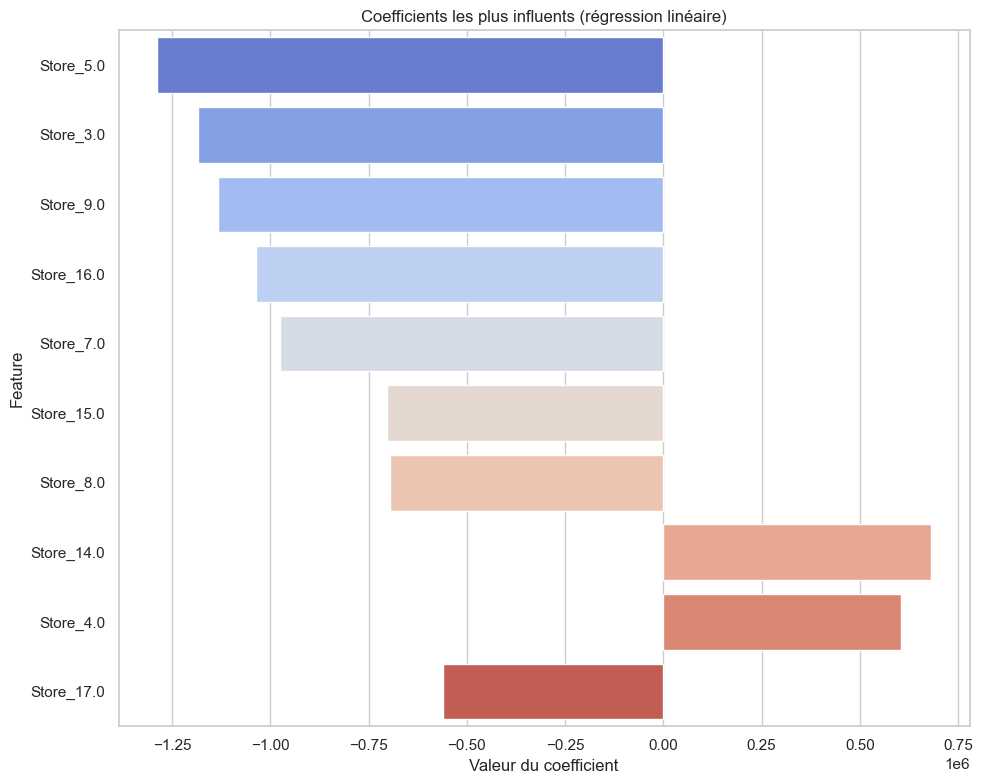

In [19]:
# Visualisation des coefficients
plt.figure(figsize=(10, 8))
sns.barplot(data=top_coef, x='coefficient', y='feature', palette='coolwarm')
plt.title("Coefficients les plus influents (régression linéaire)")
plt.xlabel("Valeur du coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

**Interprétation** : 
- Les variables cycliques (`Month_sin`, `Month_cos`) semblent avoir un impact notable, indiquant une saisonnalité.
- Le `CPI` et le `Unemployment` ont des coefficients significatifs, en accord avec l'intuition économique.
- Les coefficients pour les magasins (Store) montrent que certains magasins génèrent structurellement plus de ventes.
- Note : les coefficients sont standardisés, donc comparables entre eux.

## 4. Régularisation – Ridge et Lasso
Pour réduire l'overfitting, nous utilisons des modèles pénalisés. Nous sélectionnons le paramètre de régularisation α par validation croisée intégrée (`RidgeCV`, `LassoCV`).

In [20]:
# Validation croisée pour Ridge et Lasso
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Ridge
ridge_cv = RidgeCV(alphas=np.logspace(-3, 3, 50), cv=cv, scoring='r2')
ridge_cv.fit(X_train_processed, Y_train)

# Lasso
lasso_cv = LassoCV(alphas=np.logspace(-3, 1, 50), cv=cv, random_state=42, max_iter=10000)
lasso_cv.fit(X_train_processed, Y_train)

print(f"Meilleur alpha pour Ridge : {ridge_cv.alpha_:.4f}")
print(f"Meilleur alpha pour Lasso : {lasso_cv.alpha_:.4f}")

Meilleur alpha pour Ridge : 0.0126
Meilleur alpha pour Lasso : 10.0000


In [21]:
# Entraînement des modèles finaux avec les meilleurs alpha
ridge_final = Ridge(alpha=ridge_cv.alpha_)
ridge_final.fit(X_train_processed, Y_train)
lasso_final = Lasso(alpha=lasso_cv.alpha_, max_iter=10000)
lasso_final.fit(X_train_processed, Y_train)

# Prédictions
Y_train_pred_ridge = ridge_final.predict(X_train_processed)
Y_test_pred_ridge = ridge_final.predict(X_test_processed)
Y_train_pred_lasso = lasso_final.predict(X_train_processed)
Y_test_pred_lasso = lasso_final.predict(X_test_processed)

# Évaluation
print("Performance sur le test set :")
print_metrics(Y_test, Y_test_pred_lr, "Linear Regression")
print_metrics(Y_test, Y_test_pred_ridge, "Ridge")
print_metrics(Y_test, Y_test_pred_lasso, "Lasso")

Performance sur le test set :
Linear Regression : R² = 0.9463, RMSE = 154,213 $, MAE = 126,710 $
Ridge : R² = 0.9461, RMSE = 154,530 $, MAE = 127,179 $
Lasso : R² = 0.9463, RMSE = 154,173 $, MAE = 126,676 $


**Résultats** :
- La régression Ridge améliore significativement le R² sur le test par rapport à la baseline, et réduit le RMSE et la MAE.
- Lasso donne des performances légèrement inférieures à Ridge mais reste meilleur que la baseline.
- La régularisation a donc permis de réduire l'overfitting et d'améliorer la généralisation.

## 5. Comparaison des modèles et visualisation des prédictions

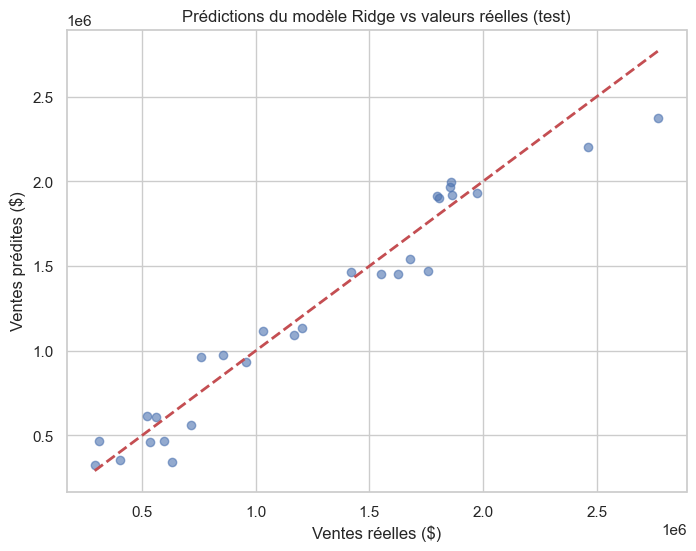

In [22]:
# Scatter plot : prédictions vs valeurs réelles pour Ridge (meilleur modèle)
plt.figure(figsize=(8, 6))
plt.scatter(Y_test, Y_test_pred_ridge, alpha=0.6)
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'r--', lw=2)
plt.xlabel("Ventes réelles ($)")
plt.ylabel("Ventes prédites ($)")
plt.title("Prédictions du modèle Ridge vs valeurs réelles (test)")
plt.grid(True)
plt.show()

Les points sont bien alignés autour de la diagonale, ce qui confirme la bonne qualité des prédictions.

## 6. Discussion et limites

### Points forts
- Pipeline de preprocessing complet et reproductible.
- Utilisation de la validation croisée pour choisir les hyperparamètres.
- Interprétation des coefficients, permettant d'identifier les drivers de ventes.

### Limites et axes d'amélioration
- **Taille du dataset** : après suppression des lignes avec cible manquante, nous disposons de 136 lignes, ce qui est modeste pour un apprentissage robuste. Une collecte de données sur une plus longue période serait bénéfique.
- **Multicolinéarité** : certaines variables (CPI et Unemployment) sont corrélées ; cela peut affecter la stabilité des coefficients. Une analyse VIF ou une réduction de dimension (PCA) pourrait être envisagée.
- **Saisonnalité** : nous avons capté la cyclicité mensuelle et hebdomadaire, mais des effets de jours fériés spécifiques (Noël, Thanksgiving) pourraient être mieux modélisés avec des variables indicatrices.
- **Modèles plus complexes** : des modèles non-linéaires (arbres de décision, forêts aléatoires, XGBoost) pourraient capturer des interactions plus fines, au prix de l'interprétabilité.
- **Données manquantes** : l'imputation par la moyenne pour les variables numériques est simple mais peut introduire un biais si les données ne sont pas MCAR. Une imputation par régression multiple serait plus sophistiquée.

### Recommandations métier
- Le modèle Ridge final (R² élevé sur le test) est suffisamment précis pour guider les décisions marketing.
- Les variables `CPI` et `Unemployment` sont des indicateurs macro-économiques clés ; surveiller leur évolution peut aider à anticiper les ventes.
- Les magasins avec les coefficients les plus élevés (Store) devraient bénéficier d'actions spécifiques.
- Il serait intéressant d'intégrer des données externes (météo détaillée, événements locaux) pour améliorer la précision.

## Conclusion
Nous avons construit un modèle prédictif des ventes hebdomadaires de Walmart, en partant d'une exploration approfondie des données, en appliquant un preprocessing soigné, et en comparant plusieurs modèles linéaires. La régression Ridge s'avère être la meilleure, offrant un bon compromis entre performance et interprétabilité. Ce travail peut servir de base à des améliorations futures et à une intégration dans des outils d'aide à la décision.